In [67]:
import numpy as np
import pickle
import stim
from matplotlib import pyplot as plt
import pygsti

In [3]:
plt.rcParams['font.size'] = 8

In [4]:
def compute_cnot_infidelity(p=1, h_scale=0):
    h_error_rates = {('H','IX'): np.sqrt(0.01*p*h_scale),
                                ('H', 'ZI'):np.sqrt(0.01*p*h_scale),
                                ('H', 'ZX'):np.sqrt(0.01*p*h_scale)}
    s_error_rates =  {('S','IX'): 0.01*p/15+0.01*p*(1-h_scale),('S', 'IY'):0.01*p/15,('S', 'IZ'):0.01*p/15,
                                  ('S', 'XX'):0.01*p/15,('S', 'XY'):0.01*p/15,('S', 'XZ'):0.01*p/15,
                                   ('S', 'YX'):0.01*p/15, ('S', 'YY'):0.01*p/15, ('S', 'YZ'):0.01*p/15,
                                  ('S', 'ZX'):0.01*p/15+0.01*p*(1-h_scale), ('S', 'ZY'):0.01*p/15, ('S', 'ZZ'):0.01*p/15, 
                                  ('S','XI'): 0.01*p/15,('S', 'YI'):0.01*p/15,('S', 'ZI'):0.01*p/15+0.01*p*(1-h_scale)}

    approx_inf = sum(j**2 for j in h_error_rates.values())+sum(j for j in s_error_rates.values())

    return approx_inf

# Decoding with decoder from Pauli twirled model vs. H-inclusive DEM

In [162]:
ds=[3,5,7]

hscales = np.linspace(0,1, num=5)

ps = np.linspace(0.3,0.5, num=5) 
ps = np.append(ps, np.linspace(0.006,0.3,num=15))
ps = np.append(ps, np.linspace(0.1,0.3,num=8))
ps = np.sort(ps)

lers_by_p = {hscale: {d:[] for d in ds} for hscale in hscales}
s_lers_by_p = {hscale: {d:[] for d in ds} for hscale in hscales}
cnot_infidelities = {hscale:[] for hscale in hscales}
for hscale in hscales:
    for p in ps:
        for d in ds:
            try:
                with open(f'data/sh_surface_code_{d}_lers_h_sweep_{p}_{hscale}.pkl', 'rb') as f:
                    lers = pickle.load(f)
                    if hscale==0:
                        total_dem = lers[2]
                        s_only_dem = lers[3]
                    lers_by_p[hscale][d].append(lers[0])
                    s_lers_by_p[hscale][d].append(lers[1])
                f.close()
            except:
                pass
        cnot_infidelity = compute_cnot_infidelity(p, hscale)
        cnot_infidelities[hscale].append(cnot_infidelity)
            
            

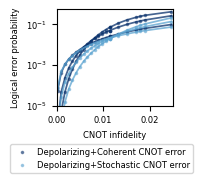

In [159]:
from matplotlib import cm

colors = cm.Blues(np.linspace(0.4, 1, 5))
#I should check that the end-of-circuuit detectors are in the correct order for the Pauli twirled model
plt.figure(figsize=(1.5,1.25))
hscale=1
for d in [3,5,7]:
    if d==3:
        plt.scatter(cnot_infidelities[hscale][:len(lers_by_p[hscale][d])], [lers_by_p[hscale][d][i] for i in range(len(lers_by_p[hscale][d]))], label='Depolarizing+Coherent CNOT error',marker='.',color=colors[-1],alpha=0.5,s=10)
    else:
        plt.scatter(cnot_infidelities[hscale][:len(lers_by_p[hscale][d])], [lers_by_p[hscale][d][i] for i in range(len(lers_by_p[hscale][d]))],marker='.',color=colors[-1],alpha=0.5,s=10)
    plt.plot(cnot_infidelities[hscale][:len(lers_by_p[hscale][d])], [lers_by_p[hscale][d][i] for i in range(len(lers_by_p[hscale][d]))], linestyle='-',color=colors[-1],alpha=0.75,linewidth=1.25)
hscale=0
for d in [3,5,7]:
    if d==3:
        plt.scatter(cnot_infidelities[hscale][:len(lers_by_p[hscale][d])], [lers_by_p[hscale][d][i] for i in range(len(lers_by_p[hscale][d]))], label='Depolarizing+Stochastic CNOT error',marker='.',color=colors[1],alpha=0.5,s=10)
    #plt.scatter(ps,s_lers, label='Pauli twirled model DEM')
    else:
        plt.scatter(cnot_infidelities[hscale][:len(lers_by_p[hscale][d])], [lers_by_p[hscale][d][i] for i in range(len(lers_by_p[hscale][d]))],marker='.',color=colors[1],alpha=0.5,s=10)
    plt.plot(cnot_infidelities[hscale][:len(lers_by_p[hscale][d])], [lers_by_p[hscale][d][i] for i in range(len(lers_by_p[hscale][d]))], linestyle='-',color=colors[1],alpha=0.75,linewidth=1.25)
    
plt.ylabel('Logical error probability', fontsize=6)
plt.xlabel('CNOT infidelity', fontsize=6)
plt.yscale('log')
plt.xlim(0, 0.025)
plt.ylim(1e-5, 0.5)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.legend(loc=(-0.4, -0.7), fontsize=6)
plt.savefig('plots/sh_sweep_comparison.pdf')

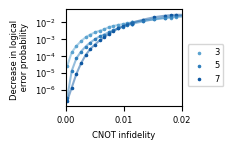

In [222]:
plt.figure(figsize=(1.5,1.25))
hscale=1
for d in [3,5,7]:
    plt.scatter(cnot_infidelities[hscale][:len(lers_by_p[hscale][d])], [s_lers_by_p[hscale][d][i]-lers_by_p[hscale][d][i] for i in range(len(lers_by_p[hscale][d]))], label=f'{d}',marker='.', color=colors[(int((d-1)/2))],s=10)
    plt.plot(cnot_infidelities[hscale][:len(lers_by_p[hscale][d])], [s_lers_by_p[hscale][d][i]-lers_by_p[hscale][d][i] for i in range(len(lers_by_p[hscale][d]))], alpha=0.5, color=colors[int((d-1)/2)])

plt.ylabel('Decrease in logical \n error probability',fontsize=6)
plt.xlabel('CNOT infidelity',fontsize=6)
plt.yscale('log')
plt.xticks(fontsize=6)
plt.yticks([1e-6,1e-5, 1e-4,1e-3,1e-2],fontsize=6)
plt.legend(loc=(1.05,0.2),fontsize=6)
plt.xlim(0,0.02)
plt.savefig('plots/sh_sweep_decoder_comparison_diff.pdf')

In [63]:
from pygsti.modelmembers.operations import ExpErrorgenOp
from pygsti.baseobjs.statespace import QubitSpace

def compute_cnot_infidelity_general(error_dict):
    #process the dictionary of error rates into required format
    edict_processed = {}
    edict_processed = error_dict

    pm_edict = {'Gh':ExpErrorgenOp(pygsti.modelmembers.operations.LindbladErrorgen.from_elementary_errorgens(edict_processed['Gh'], state_space=QubitSpace(1))).to_dense(),
            'Gcnot':ExpErrorgenOp(pygsti.modelmembers.operations.LindbladErrorgen.from_elementary_errorgens(edict_processed['Gcnot'], state_space=QubitSpace(2))).to_dense(),
            'Gi':np.eye(4)}

    
    return 1-np.trace(pm_edict['Gcnot'])/16

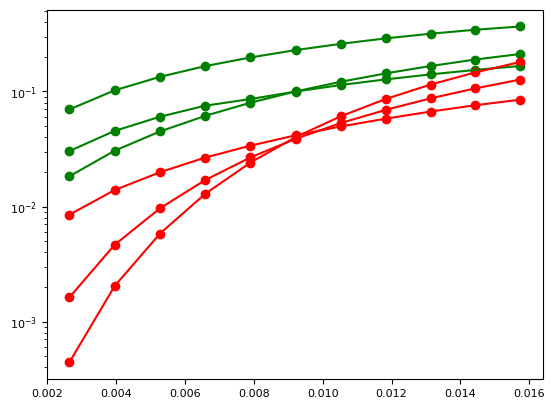

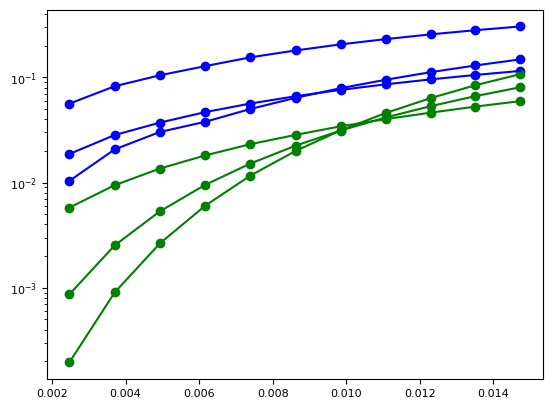

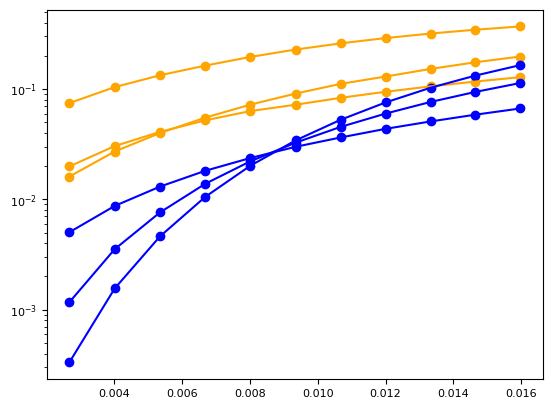

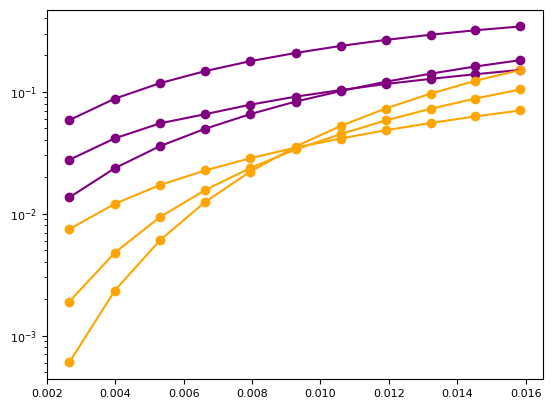

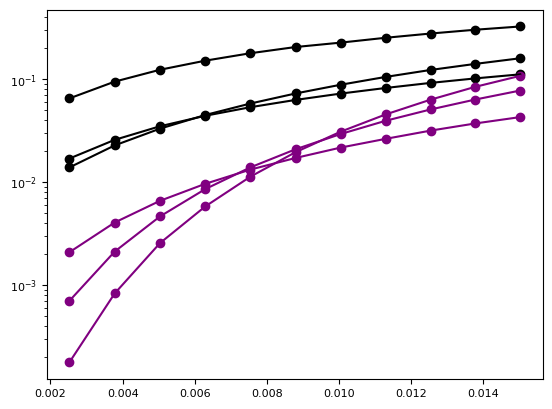

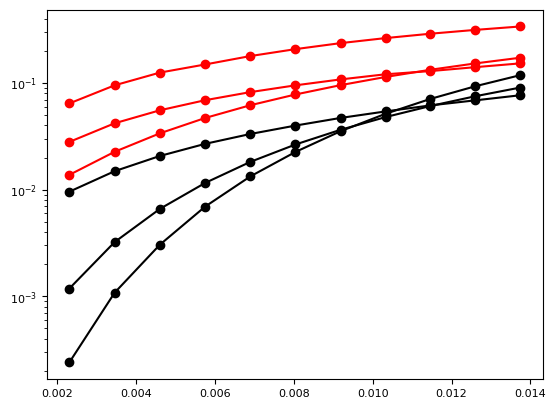

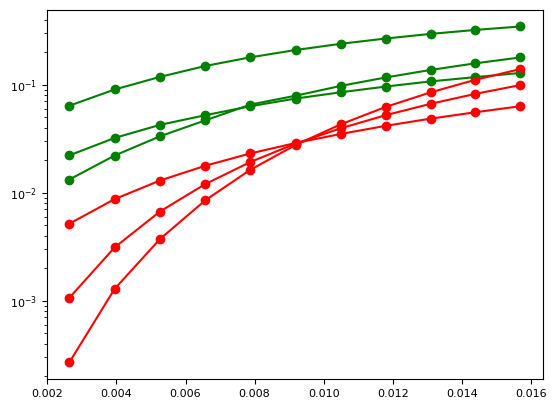

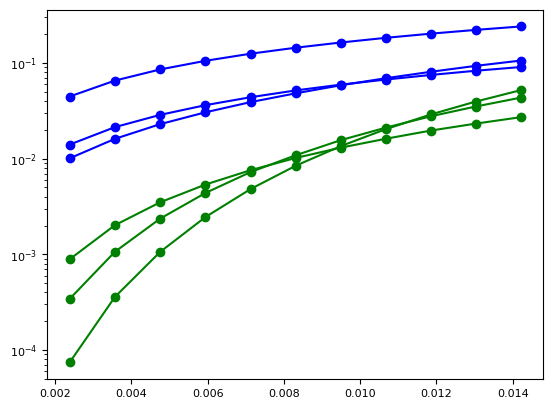

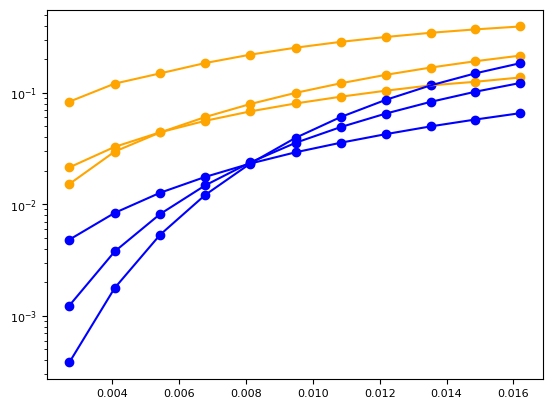

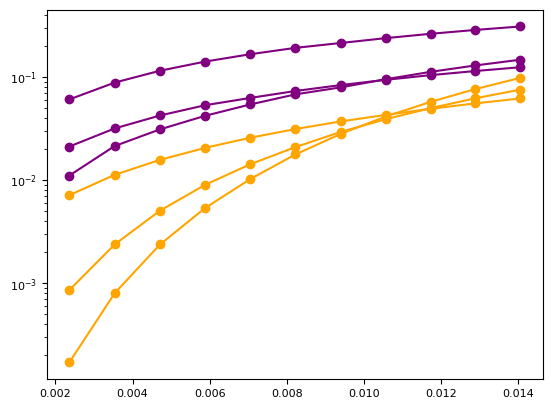

In [70]:
ds=[3,5,7]
ps = np.linspace(1.8,10.8, num=11)
colors = ['red', 'green', 'blue', 'orange', 'purple', 'black']*2
lers_by_p = {idx: {d:[] for d in ds} for idx in range(10)}
s_lers_by_p = {idx: {d:[] for d in ds} for idx in range(10)}
cnot_infidelities = {idx:[] for idx in range(10)}
for idx in range(10):
    for p in ps:
        for d in ds:
            with open(f'data/surface_code_{d}_random_models_{idx}_strength_{p}.pkl', 'rb') as f:
                lers = pickle.load(f)
            f.close()
            lers_by_p[idx][d].append(lers[0])

        cnot_infidelity = compute_cnot_infidelity_general(lers[-1])
        cnot_infidelities[idx].append(cnot_infidelity)
    for d in ds:
        plt.scatter(cnot_infidelities[idx], lers_by_p[idx][d], color=colors[idx])
        plt.plot(cnot_infidelities[idx], lers_by_p[idx][d], color=colors[idx])
    plt.yscale('log')
    plt.show()

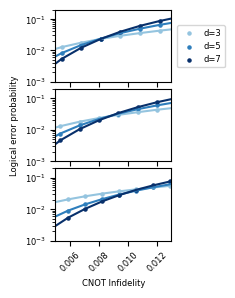

In [160]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from matplotlib import cm

ds = [3, 5, 7]
ps = np.linspace(1.8, 10.8, num=11)  # You can consider using a log scale if needed
colors = cm.Blues(np.linspace(0.4, 1, 5)) #colors = ['red', 'green', 'blue', 'orange', 'purple']
lers_by_p = {idx: {d: [] for d in ds} for idx in range(10)}
cnot_infidelities = {idx: [] for idx in range(10)}

# Create a figure with 5 subplots
fig, axs = plt.subplots(3, 1, figsize=(1.5, 3), sharex=True)

for j, idx in enumerate([8,2,9]):  # Loop through idx from 0 to 4
    for p in ps:
        for d in ds:
            with open(f'data/surface_code_{d}_random_models_{idx}_strength_{p}.pkl', 'rb') as f:
                lers = pickle.load(f)
            lers_by_p[idx][d].append(lers[0])

        cnot_infidelity = compute_cnot_infidelity_general(lers[-1])
        cnot_infidelities[idx].append(cnot_infidelity)

    # Plotting in the corresponding subplot
    for d in ds:
        axs[j].scatter(cnot_infidelities[idx], lers_by_p[idx][d], color=colors[(d-3)], label=f'd={d}', s=5)  # Smaller markers
        axs[j].plot(cnot_infidelities[idx], lers_by_p[idx][d], color=colors[(d-3)])

    axs[j].set_yscale('log')
    axs[j].set_xlim(0.005, 0.013)
    axs[j].set_ylim(0.001, 0.2)
    axs[j].tick_params(labelsize=6)
    #axs[idx].set_title(f'Plot for idx={idx}')
axs[1].set_ylabel('Logical error probability',fontsize=6)
axs[0].legend(loc=(1.05,0.2),fontsize=6)

# Set common x-label
axs[-1].set_xlabel('CNOT Infidelity',fontsize=6)

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.1) 
plt.xticks([0.006,0.008,0.010,0.012],rotation=45)

#plt.tight_layout()
plt.savefig('plots/surface_random_model_thresholds.pdf')